# Métricas de Avaliação — One-2-3-45 vs Point-E vs Shap-E

**Métricas calculadas:**
1. **CLIP Similarity** — semelhança entre imagem de entrada e views renderizadas do mesh (sem GT necessário)
2. **F-Score** — comparação geométrica entre meshes (usando One-2-3-45 como referência, ou entre todos)

**Pré-requisitos:** meshes `.ply` gerados por cada método + imagem de entrada original

## Célula 1 — Setup

In [1]:
import os

# Montar Drive
if os.path.exists('/content/drive/MyDrive'):
    print('Drive já montado.')
else:
    from google.colab import drive
    drive.mount('/content/drive')

# Instalar dependências
!pip install -q trimesh scipy numpy matplotlib
!pip install -q git+https://github.com/openai/CLIP.git

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 45.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00


## Célula 2 — Configurar Caminhos

**AJUSTE AQUI** os caminhos para seus arquivos no Drive.

In [2]:
# ============================================================
# AJUSTE ESTES CAMINHOS
# ============================================================

# Imagem de entrada original usada para gerar os meshes
INPUT_IMAGE = '/content/drive/MyDrive/Ufma/ECP/CG/One-2-3-45-master/inputs/edited/busto-edited.png'

# Meshes gerados por cada método
MESH_ONE2345 = '/content/drive/MyDrive/Ufma/ECP/CG/One-2-3-45-master/exp/busto-edited/mesh.ply'
MESH_POINT_E = '/content/drive/MyDrive/Ufma/ECP/CG/modelos_point_e/busto-edited_point_e.ply'
MESH_SHAP_E = '/content/drive/MyDrive/Ufma/ECP/CG/modelos_shap_e/busto-edited_shap_e.ply'

# ============================================================
# Verificar se os arquivos existem
for nome, path in [('Input', INPUT_IMAGE), ('One-2-3-45', MESH_ONE2345), ('Point-E', MESH_POINT_E), ('Shap-E', MESH_SHAP_E)]:
    status = '✓' if os.path.exists(path) else '✗ NÃO ENCONTRADO'
    print(f'{status} {nome}: {path}')

✓ Input: /content/drive/MyDrive/Ufma/ECP/CG/One-2-3-45-master/inputs/edited/busto-edited.png
✓ One-2-3-45: /content/drive/MyDrive/Ufma/ECP/CG/One-2-3-45-master/exp/busto-edited/mesh.ply
✓ Point-E: /content/drive/MyDrive/Ufma/ECP/CG/modelos_point_e/busto-edited_point_e.ply
✓ Shap-E: /content/drive/MyDrive/Ufma/ECP/CG/modelos_shap_e/busto-edited_shap_e.ply


## Célula 3 — Funções de Renderização (sem Blender)

Renderiza 8 views do mesh usando pyrender/trimesh (headless, não precisa de Blender).

In [3]:
import trimesh
import numpy as np
from PIL import Image
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import io

def render_mesh_views(mesh_path, n_views=8, resolution=256):
    """
    Renderiza n_views do mesh em diferentes ângulos usando matplotlib.
    Retorna lista de PIL Images.
    """
    # Carregar mesh
    mesh = trimesh.load(mesh_path, force='mesh')

    # Normalizar para esfera unitária
    centroid = mesh.vertices.mean(axis=0)
    mesh.vertices -= centroid
    scale = np.max(np.linalg.norm(mesh.vertices, axis=1))
    if scale > 0:
        mesh.vertices /= scale

    vertices = mesh.vertices
    faces = mesh.faces

    # Tentar pegar cores de vértice
    face_colors = None
    if hasattr(mesh.visual, 'vertex_colors') and mesh.visual.vertex_colors is not None:
        vc = mesh.visual.vertex_colors[:, :3] / 255.0
        face_colors = vc[faces].mean(axis=1)  # cor média por face

    images = []
    azimuths = np.linspace(0, 360, n_views, endpoint=False)
    elevation = 30

    # Subsample faces para renderização rápida (max 50k faces)
    max_faces = 50000
    if len(faces) > max_faces:
        idx = np.random.choice(len(faces), max_faces, replace=False)
        render_faces = faces[idx]
        render_colors = face_colors[idx] if face_colors is not None else None
    else:
        render_faces = faces
        render_colors = face_colors

    for azimuth in azimuths:
        fig = plt.figure(figsize=(4, 4), dpi=resolution//4)
        ax = fig.add_subplot(111, projection='3d')

        # Criar polígonos
        poly = Poly3DCollection(vertices[render_faces], alpha=1.0)
        if render_colors is not None:
            poly.set_facecolor(render_colors)
        else:
            poly.set_facecolor([0.7, 0.7, 0.8])
        poly.set_edgecolor('none')
        ax.add_collection3d(poly)

        # Configurar câmera
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_zlim(-1, 1)
        ax.view_init(elev=elevation, azim=azimuth)
        ax.set_axis_off()
        ax.set_facecolor('white')
        fig.patch.set_facecolor('white')

        # Converter para PIL Image
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0, dpi=resolution//4)
        plt.close(fig)
        buf.seek(0)
        img = Image.open(buf).convert('RGB').resize((resolution, resolution))
        images.append(img)

    return images

print('✓ Funções de renderização carregadas (matplotlib).')

✓ Funções de renderização carregadas (matplotlib).


## Célula 4 — CLIP Similarity (imagem de entrada vs views do mesh)

In [4]:
import torch
import clip

device = 'cuda' if torch.cuda.is_available() else 'cpu'
clip_model, clip_preprocess = clip.load('ViT-B/32', device=device)

def compute_clip_score(input_image_path, mesh_path, n_views=8):
    """
    Calcula CLIP similarity entre a imagem de entrada e views renderizadas do mesh.
    Retorna: média, lista de scores por view
    """
    # Carregar imagem de entrada
    input_img = clip_preprocess(Image.open(input_image_path).convert('RGB')).unsqueeze(0).to(device)

    with torch.no_grad():
        input_feat = clip_model.encode_image(input_img)
        input_feat = input_feat / input_feat.norm(dim=-1, keepdim=True)

    # Renderizar views do mesh
    views = render_mesh_views(mesh_path, n_views=n_views)

    # Calcular CLIP similarity para cada view
    scores = []
    for view in views:
        view_tensor = clip_preprocess(view.convert('RGB')).unsqueeze(0).to(device)
        with torch.no_grad():
            view_feat = clip_model.encode_image(view_tensor)
            view_feat = view_feat / view_feat.norm(dim=-1, keepdim=True)
        sim = (input_feat @ view_feat.T).item() * 100
        scores.append(sim)

    return np.mean(scores), scores

# Calcular CLIP Similarity para cada método
print('='*55)
print('CLIP SIMILARITY (imagem de entrada vs views do mesh)')
print('Quanto maior, melhor. Escala: 0-100')
print('='*55)

resultados_clip = {}

for nome, mesh_path in [('One-2-3-45', MESH_ONE2345), ('Point-E', MESH_POINT_E), ('Shap-E', MESH_SHAP_E)]:
    if os.path.exists(mesh_path):
        mean_score, all_scores = compute_clip_score(INPUT_IMAGE, mesh_path, n_views=8)
        resultados_clip[nome] = mean_score
        print(f'{nome:12s} | CLIP: {mean_score:.2f}  (views: {["{:.1f}".format(s) for s in all_scores]})')
    else:
        print(f'{nome:12s} | Mesh não encontrado')

print()

100%|████████████████████████████████████████| 338M/338M [00:00<00:00, 363MiB/s]


CLIP SIMILARITY (imagem de entrada vs views do mesh)
Quanto maior, melhor. Escala: 0-100
One-2-3-45   | CLIP: 52.08  (views: ['55.0', '52.7', '52.5', '51.3', '52.0', '53.6', '50.3', '49.3'])
Point-E      | CLIP: 50.73  (views: ['52.7', '48.9', '50.2', '51.6', '51.7', '50.2', '51.1', '49.5'])
Shap-E       | CLIP: 50.34  (views: ['49.4', '46.0', '54.0', '51.2', '48.4', '52.9', '49.8', '50.9'])



## Célula 5 — F-Score (comparação geométrica entre meshes)

In [5]:
from scipy.spatial import cKDTree

def sample_points(mesh_path, n_points=100000):
    """Amostra pontos uniformemente da superfície do mesh."""
    mesh = trimesh.load(mesh_path, force='mesh')
    points, _ = trimesh.sample.sample_surface(mesh, n_points)
    return points

def normalize_points(points):
    """Centraliza e normaliza para esfera unitária."""
    centroid = points.mean(axis=0)
    points = points - centroid
    scale = np.max(np.linalg.norm(points, axis=1))
    if scale > 0:
        points = points / scale
    return points

def compute_fscore(points_1, points_2, threshold=0.01):
    """
    F-Score entre dois point clouds.
    Precision: % pontos de 1 que estão perto de 2
    Recall: % pontos de 2 que estão perto de 1
    """
    tree_1 = cKDTree(points_1)
    tree_2 = cKDTree(points_2)

    dist_1to2, _ = tree_2.query(points_1)
    dist_2to1, _ = tree_1.query(points_2)

    precision = (dist_1to2 < threshold).mean() * 100
    recall = (dist_2to1 < threshold).mean() * 100

    if precision + recall > 0:
        fscore = 2 * precision * recall / (precision + recall)
    else:
        fscore = 0.0

    return fscore, precision, recall

def compute_chamfer_distance(points_1, points_2):
    """Chamfer Distance (média das distâncias mínimas)."""
    tree_1 = cKDTree(points_1)
    tree_2 = cKDTree(points_2)

    dist_1to2, _ = tree_2.query(points_1)
    dist_2to1, _ = tree_1.query(points_2)

    cd = (dist_1to2.mean() + dist_2to1.mean()) / 2
    return cd

# ============================================================
# Comparar meshes entre si (par a par)
# ============================================================

print('='*55)
print('F-SCORE & CHAMFER DISTANCE (comparação entre meshes)')
print('F-Score: maior = melhor | Chamfer: menor = melhor')
print('='*55)

# Carregar point clouds
meshes = {}
for nome, path in [('One-2-3-45', MESH_ONE2345), ('Point-E', MESH_POINT_E), ('Shap-E', MESH_SHAP_E)]:
    if os.path.exists(path):
        pts = normalize_points(sample_points(path, n_points=100000))
        meshes[nome] = pts
        print(f'  ✓ {nome} carregado ({len(pts)} pontos)')
    else:
        print(f'  ✗ {nome} não encontrado')

print()

# Comparar todos os pares
nomes = list(meshes.keys())
print(f'{"Referência":12s} vs {"Comparado":12s} | F-Score | Chamfer Dist')
print('-'*60)

resultados_fscore = {}

for i, ref_nome in enumerate(nomes):
    for j, comp_nome in enumerate(nomes):
        if i >= j:
            continue
        fs, prec, rec = compute_fscore(meshes[ref_nome], meshes[comp_nome], threshold=0.02)
        cd = compute_chamfer_distance(meshes[ref_nome], meshes[comp_nome])
        print(f'{ref_nome:12s} vs {comp_nome:12s} | {fs:6.1f}  | {cd:.5f}')
        resultados_fscore[f'{ref_nome} vs {comp_nome}'] = {'F-Score': fs, 'Chamfer': cd}

F-SCORE & CHAMFER DISTANCE (comparação entre meshes)
F-Score: maior = melhor | Chamfer: menor = melhor
  ✓ One-2-3-45 carregado (100000 pontos)
  ✓ Point-E carregado (100000 pontos)
  ✓ Shap-E carregado (100000 pontos)

Referência   vs Comparado    | F-Score | Chamfer Dist
------------------------------------------------------------
One-2-3-45   vs Point-E      |   14.2  | 0.09725
One-2-3-45   vs Shap-E       |   12.7  | 0.10628
Point-E      vs Shap-E       |   15.5  | 0.08968


## Célula 6 — Tabela Final de Resultados

In [6]:
import pandas as pd

# Montar tabela resumo
rows = []
for nome in ['One-2-3-45', 'Point-E', 'Shap-E']:
    row = {'Método': nome}
    row['CLIP Similarity ↑'] = resultados_clip.get(nome, '-')

    # F-Score vs One-2-3-45 (se não for ele mesmo)
    if nome != 'One-2-3-45' and f'One-2-3-45 vs {nome}' in resultados_fscore:
        row['F-Score vs One-2-3-45 ↑'] = resultados_fscore[f'One-2-3-45 vs {nome}']['F-Score']
        row['Chamfer vs One-2-3-45 ↓'] = resultados_fscore[f'One-2-3-45 vs {nome}']['Chamfer']
    else:
        row['F-Score vs One-2-3-45 ↑'] = '(ref)'
        row['Chamfer vs One-2-3-45 ↓'] = '(ref)'

    rows.append(row)

df = pd.DataFrame(rows)
print('\n' + '='*70)
print('RESULTADOS FINAIS')
print('='*70)
print(df.to_string(index=False))
print('\n')
print('CLIP Similarity: semelhança visual com imagem de entrada (maior = melhor)')
print('F-Score: semelhança geométrica com One-2-3-45 como referência (maior = mais parecido)')
print('Chamfer Distance: distância geométrica (menor = mais parecido)')


RESULTADOS FINAIS
    Método  CLIP Similarity ↑ F-Score vs One-2-3-45 ↑ Chamfer vs One-2-3-45 ↓
One-2-3-45          52.081299                   (ref)                   (ref)
   Point-E          50.732422               14.230708                0.097254
    Shap-E          50.338745               12.728073                0.106283


CLIP Similarity: semelhança visual com imagem de entrada (maior = melhor)
F-Score: semelhança geométrica com One-2-3-45 como referência (maior = mais parecido)
Chamfer Distance: distância geométrica (menor = mais parecido)


## Célula 7 — Visualizar views renderizadas


One-2-3-45


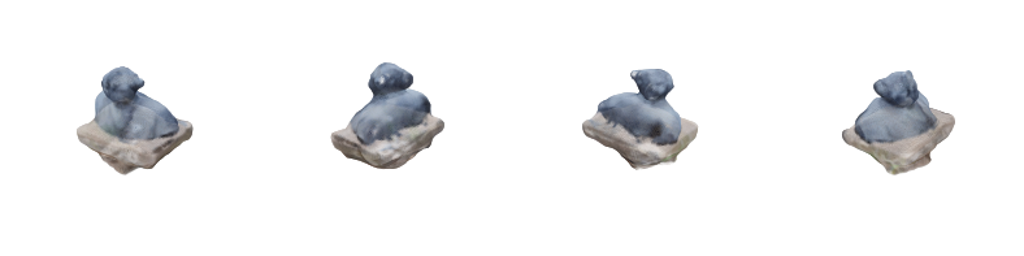


Point-E


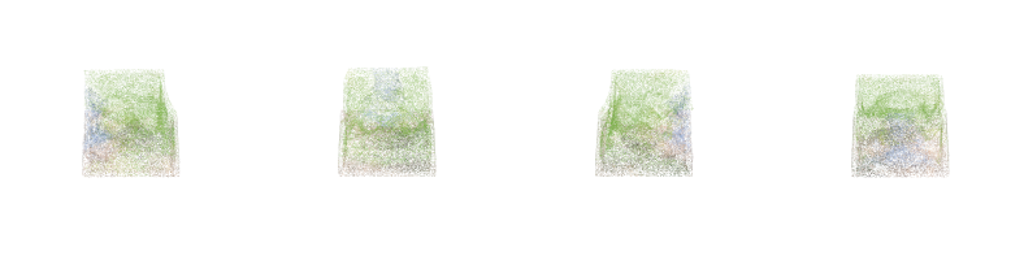


Shap-E


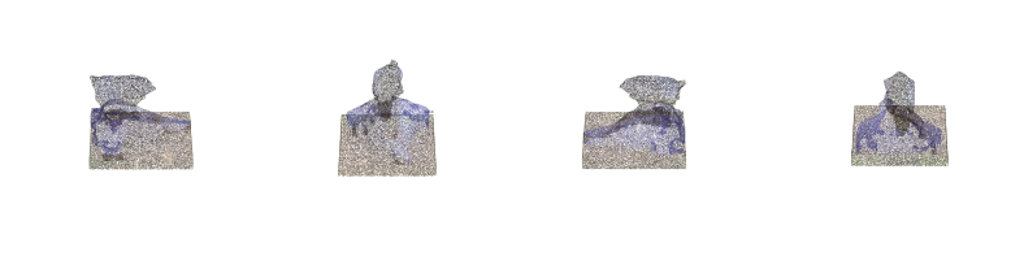

In [7]:
from IPython.display import display

for nome, mesh_path in [('One-2-3-45', MESH_ONE2345), ('Point-E', MESH_POINT_E), ('Shap-E', MESH_SHAP_E)]:
    if not os.path.exists(mesh_path):
        continue
    print(f'\n{"="*40}')
    print(f'{nome}')
    print(f'{"="*40}')

    views = render_mesh_views(mesh_path, n_views=4, resolution=256)

    # Grid 1x4
    grid = Image.new('RGB', (256*4, 256))
    for i, v in enumerate(views):
        grid.paste(v, (256*i, 0))
    display(grid)

## Célula 8 — Processar múltiplas imagens

Se você tem vários objetos, coloque todos na mesma estrutura e rode em batch.

In [8]:
# Ajuste os caminhos base
BASE_ONE2345 = '/content/drive/MyDrive/Ufma/ECP/CG/One-2-3-45-master/exp'
BASE_POINT_E = '/content/drive/MyDrive/Ufma/ECP/CG/modelos_point_e'
BASE_SHAP_E = '/content/drive/MyDrive/Ufma/ECP/CG/modelos_shap_e'
BASE_INPUTS = '/content/drive/MyDrive/Ufma/ECP/CG/One-2-3-45-master/inputs'

# Listar objetos disponíveis (baseado nas pastas do One-2-3-45)
objetos = [d for d in os.listdir(BASE_ONE2345) if os.path.isdir(os.path.join(BASE_ONE2345, d))]
print(f'Objetos encontrados: {len(objetos)}')
for obj in objetos:
    print(f'  - {obj}')

# Calcular métricas para cada objeto
all_results = []

for obj in objetos:
    print(f'\nProcessando: {obj}')

    # Procurar imagem de entrada
    input_img = None
    for ext in ['.png', '.jpg', '.jpeg']:
        candidate = os.path.join(BASE_INPUTS, obj + ext)
        if os.path.exists(candidate):
            input_img = candidate
            break

    if input_img is None:
        print(f'  ⚠ Imagem de entrada não encontrada para {obj}')
        continue

    mesh_paths = {
        'One-2-3-45': os.path.join(BASE_ONE2345, obj, 'mesh.ply'),
        'Point-E': os.path.join(BASE_POINT_E, obj + '.ply'),
        'Shap-E': os.path.join(BASE_SHAP_E, obj + '.ply'),
    }

    for metodo, mpath in mesh_paths.items():
        if os.path.exists(mpath):
            try:
                clip_score, _ = compute_clip_score(input_img, mpath, n_views=8)
                all_results.append({'Objeto': obj, 'Método': metodo, 'CLIP ↑': clip_score})
                print(f'  {metodo:12s} | CLIP: {clip_score:.2f}')
            except Exception as e:
                print(f'  {metodo:12s} | Erro: {e}')

# Tabela final
if all_results:
    df_all = pd.DataFrame(all_results)
    print('\n\n' + '='*50)
    print('MÉDIA POR MÉTODO')
    print('='*50)
    print(df_all.groupby('Método')['CLIP ↑'].mean().sort_values(ascending=False).to_string())

Objetos encontrados: 10
  - 01_wild_hydrant
  - {img}
  - busto
  - canhao
  - leao
  - poste
  - busto-edited
  - canhao-edited
  - leao-edited
  - poste-edited

Processando: 01_wild_hydrant
  ⚠ Imagem de entrada não encontrada para 01_wild_hydrant

Processando: {img}
  ⚠ Imagem de entrada não encontrada para {img}

Processando: busto
  One-2-3-45   | CLIP: 53.82

Processando: canhao
  One-2-3-45   | CLIP: 57.58

Processando: leao
  One-2-3-45   | CLIP: 63.36

Processando: poste
  One-2-3-45   | CLIP: 56.04

Processando: busto-edited
  ⚠ Imagem de entrada não encontrada para busto-edited

Processando: canhao-edited
  ⚠ Imagem de entrada não encontrada para canhao-edited

Processando: leao-edited
  ⚠ Imagem de entrada não encontrada para leao-edited

Processando: poste-edited
  ⚠ Imagem de entrada não encontrada para poste-edited


MÉDIA POR MÉTODO
Método
One-2-3-45    57.701111
